In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Importing DataSets

In [211]:
# 1. Pehle teeno datasets ko read kar ke DataFrames bana lein
ranking = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\EDA\\Fifa_WorldCup\\fifa_ranking_2022-10-06.csv') 
matches = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\EDA\\Fifa_WorldCup\\matches_1930_2022.csv')      
world_cup = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\EDA\\Fifa_WorldCup\\world_cup.csv')            

In [212]:
ranking_df = ranking.copy() 
matches_df =  matches.copy()    
world_cup_df = world_cup.copy()

to excel

In [213]:
# 2. Excel writer object banayein (File ka naam jo aap rakhna chahein)
with pd.ExcelWriter('FIFA_World_Cup_Data.xlsx', engine='openpyxl') as writer:
    
    # 3. Har DataFrame ko alag sheet (page) par write karein
    ranking.to_excel(writer, sheet_name='FIFA Rankings', index=False)
    matches.to_excel(writer, sheet_name='Matches History', index=False)
    world_cup.to_excel(writer, sheet_name='World Cup Summary', index=False)
    
    
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        for col in worksheet.columns:
            # Column mein majood sab se lambe text ki length nikalen
            max_len = max(len(str(cell.value or '')) for cell in col)
            col_letter = col[0].column_letter  # Column ka letter (A, B, C...)
            # Padding ke sath width set karein
            worksheet.column_dimensions[col_letter].width = max(max_len + 3, 10)

In [214]:
ranking_df.head(5) #2018 - 2022

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [215]:
world_cup_df.head(5)

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [216]:
matches.head(5)

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [217]:
print(matches_df.shape)
print(world_cup_df.shape)
print(ranking_df.shape)

(964, 44)
(22, 9)
(211, 7)


### Checking For null values

In [218]:
matches_df.isnull().sum() / len(matches) * 100

home_team                           0.000000
away_team                           0.000000
home_score                          0.000000
home_xg                            86.721992
home_penalty                       96.369295
away_score                          0.000000
away_xg                            86.721992
away_penalty                       96.369295
home_manager                        0.000000
home_captain                       33.195021
away_manager                        0.000000
away_captain                       33.195021
Attendance                          0.000000
Venue                               0.000000
Officials                          26.452282
Round                               0.000000
Date                                0.000000
Score                               0.000000
Referee                            26.452282
Notes                              92.427386
Host                                0.000000
Year                                0.000000
home_goal 

In [219]:
world_cup_df.isnull().sum()

Year             0
Host             0
Teams            0
Champion         0
Runner-Up        0
TopScorrer       0
Attendance       0
AttendanceAvg    0
Matches          0
dtype: int64

In [220]:
ranking_df.isnull().sum()

team               0
team_code          0
association        0
rank               0
previous_rank      0
points             0
previous_points    0
dtype: int64

### Checking For duplicates

In [221]:
print(matches_df.duplicated().sum())
print(ranking_df.duplicated().sum())
print(world_cup_df.duplicated().sum())

0
0
0


In [222]:
matches_df['home_team'].unique()

<StringArray>
[             'Argentina',                'Croatia',                 'France',
                'Morocco',                'England',            'Netherlands',
               'Portugal',                  'Japan',                 'Brazil',
         'Korea Republic',                  'Ghana',               'Cameroon',
                 'Serbia',                 'Canada',             'Costa Rica',
              'Australia',                'Tunisia',           'Saudi Arabia',
                 'Poland',                'Ecuador',                'IR Iran',
                  'Wales',                'Belgium',                  'Spain',
                  'Qatar',            'Switzerland',                'Uruguay',
                'Germany',                'Denmark',                 'Mexico',
                'Senegal',          'United States',                 'Sweden',
                 'Russia',               'Colombia',                 'Panama',
                'Iceland',            

In [223]:
# replace same countries with different entires with one common name. 
germany_mapping={
    'Germany DR':'Germany',
    'West Germany':'Germany'
}

korea_mapping = {
    'Korea Republic':'South Korea',
    'Korea DPR' : 'North Korea'
}

matches_df['home_team'] = matches_df['home_team'].replace(germany_mapping)
matches_df['away_team'] = matches_df['away_team'].replace(germany_mapping)


matches_df['home_team'] = matches_df['home_team'].replace(korea_mapping)
matches_df['away_team'] = matches_df['away_team'].replace(korea_mapping)



### Let's Start EDA

 - Total number of matches played till 2022.
 - Total goal Scored (Penalty Goals).
 - Average goal scored per match.
 - Total Attendence over time.
 - Average attendance over time.

In [224]:
# - Total number of matches played till 2022. 
print(f'Total Number of Matches : {len(matches_df)}')

Total Number of Matches : 964


In [225]:
# - Total goal Scored (Penalty Goals). 
regular_goals = (matches_df['home_score'] + matches_df['away_score']).sum()

matches_df['home_penalty'] = matches_df['home_penalty'].fillna(0)
matches_df['away_penalty'] = matches_df['away_penalty'].fillna(0)
penalty_goals = (matches_df['home_penalty'] + matches_df['away_penalty']).sum()

total_goals = regular_goals + penalty_goals


print(f"Total Regular Goals: {regular_goals}")
print(f"Total Penalty Shootout Goals: {int(penalty_goals)}")
print(f"Grand Total Goals in World Cup History: {int(total_goals)}")

Total Regular Goals: 2720
Total Penalty Shootout Goals: 222
Grand Total Goals in World Cup History: 2942


In [226]:
matches_df

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,0.0,1,1.2,0.0,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,0.0,0,0.9,0.0,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,0.0,0,0.5,0.0,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,0.0,0,0.9,0.0,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1,NaN,0.0,0,NaN,0.0,Francisco Olazar,Manuel Ferreira,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960,Yugoslavia,Brazil,2,NaN,0.0,1,NaN,0.0,Bosko Simonovic,Milutin Ivković,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
961,Romania,Peru,3,NaN,0.0,1,NaN,0.0,Octav Luchide,Emerich Vogl,...,NaN,NaN,NaN,Plácido Galindo · 70,NaN,NaN,NaN,NaN,NaN,NaN
962,United States,Belgium,3,NaN,0.0,0,NaN,0.0,Bob Millar,Tom Florie,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [227]:
# Calculate the average goals per match
avg_goals = regular_goals / len(matches_df)

# Print the result rounded to 2 decimal places
print(f"Average goals scored per match: {avg_goals:.2f}")

Average goals scored per match: 2.82


In [228]:
#  - Total Attendence over time. 
total_attendance = (matches_df['Attendance']).sum()
print(f"Total Attendance Over Time: {total_attendance}")

Total Attendance Over Time: 44048413


In [229]:
#  - Average attendance over time. 
avg_attandence = total_attendance / len(matches_df)

# Print the result rounded to 2 decimal places
print(f"Average Attendance Over Time: {avg_attandence:.2f}")

Average Attendance Over Time: 45693.37


 - Times a particular country is winner, runner up or second runner up.
 - In which year a particular team participated.
 - Average goal scored per match.
 - Total Attendence over time.
 - Average attendance over time.

In [230]:
# WINNER

# 1. Pehle world_cup DataFrame mein Germany ke names fix karein
world_cup['Champion'] = world_cup['Champion'].replace(germany_mapping)

# 2. Phir dobara counts aggregate karein
winner = world_cup['Champion'].value_counts().reset_index()

# 3. Pie chart ko plot karein (Ab West Germany aur Germany merge ho jayenge!)
fig = px.pie(winner, values='count', names='Champion', title='Number of times a country won Fifa world cup')


#customize 
fig.update_traces(textinfo='label+value')
fig.show()

### Conclusions

  - Brazil won the most number of World Cup titles, followed by Italy and Argentina.
  - Germany and West Germany appear as separate entries but hold a combined total of 4 titles.
  - England and Spain are the most notable nations to win the trophy only 1 time.

In [231]:
# First runner and 2nd runner up
matches_df['home_total'] = matches_df['home_score'] + matches_df['home_penalty']
matches_df['away_total'] = matches_df['away_score'] + matches_df['away_penalty']


runner = matches_df[matches_df['Round'] == 'Final'].copy()
third = matches_df[matches_df['Round'] == 'Third-place match'].copy()

In [232]:
def get_runner_up(row):
    
    # for first runner up
    
    if (row['home_total'] > row['away_total']):
        return row['away_team']
    else:
        return row['home_team']
    
    
def get_2ndrunner_up(row):
    
    # for first runner up
    
    if (row['home_total'] > row['away_total']):
        return row['home_team']
    else:
        return row['away_team']

In [233]:
runner['runner_up'] = runner.apply(get_runner_up,axis=1)
third['third_place'] = third.apply(get_2ndrunner_up,axis=1)

In [234]:
runner['runner_up'].value_counts()
third['third_place'].value_counts()

third_place
Germany        4
Croatia        2
France         2
Poland         2
Brazil         2
Belgium        1
Netherlands    1
Türkiye        1
Sweden         1
Italy          1
Portugal       1
Chile          1
Austria        1
Name: count, dtype: int64

In [235]:
trace1 = go.Bar(x=runner['runner_up'].value_counts().index,y=runner['runner_up'].value_counts(),name='Fisrt Runner Up')
trace2 = go.Bar(x=third['third_place'].value_counts().index,y=third['third_place'].value_counts(),name='Second Runner Up')

fig = make_subplots(rows=1,cols=2,subplot_titles=('Fisrt Runner Up','Second Runner Up'))

fig.add_trace(trace1,row=1,col=1)
fig.add_trace(trace2,row=1,col=2)
fig.show()

### Conclusions

 - Germany won the most number of First runner up titles, followed by Argentina and Netherlands.
 - Germany also won the most number of Second runner up titles.
 - Croatia, France, Poland, and Brazil share the second spot for winning the most Second runner up titles.

In [236]:
matches_df['Year'].value_counts()

Year
2022    64
2018    64
2014    64
2010    64
2006    64
2002    64
1998    64
1994    52
1990    52
1986    52
1982    52
1978    38
1974    38
1958    35
1970    32
1966    32
1962    32
1954    26
1950    22
1938    18
1930    18
1934    17
Name: count, dtype: int64

In [237]:
#1. concatinate
#2. Use set function for removing duplicates from the concate list
#3. created a list

data = matches_df.groupby('Year').agg(home=('home_team',list),away=('away_team',list))
data['teams'] = data.apply(lambda x: list(set(x['home']+x['away'])),axis=1)

In [238]:
data['count'] = data['teams'].apply(len)

In [239]:
#data['teams'].explode().reset_index().pivot_table(index='Year',columns='teams',values='Year').T
# or 
data_pivot = data['teams'].explode().reset_index().pivot_table(index='teams',columns='Year',values='Year')

In [240]:
# fill na with 0 

data_pivot.fillna(0,inplace=True)

# fill the values with 1 so the heatmap will be looking clear 

data_pivot = data_pivot.map(lambda x: 1 if x > 0 else 0)

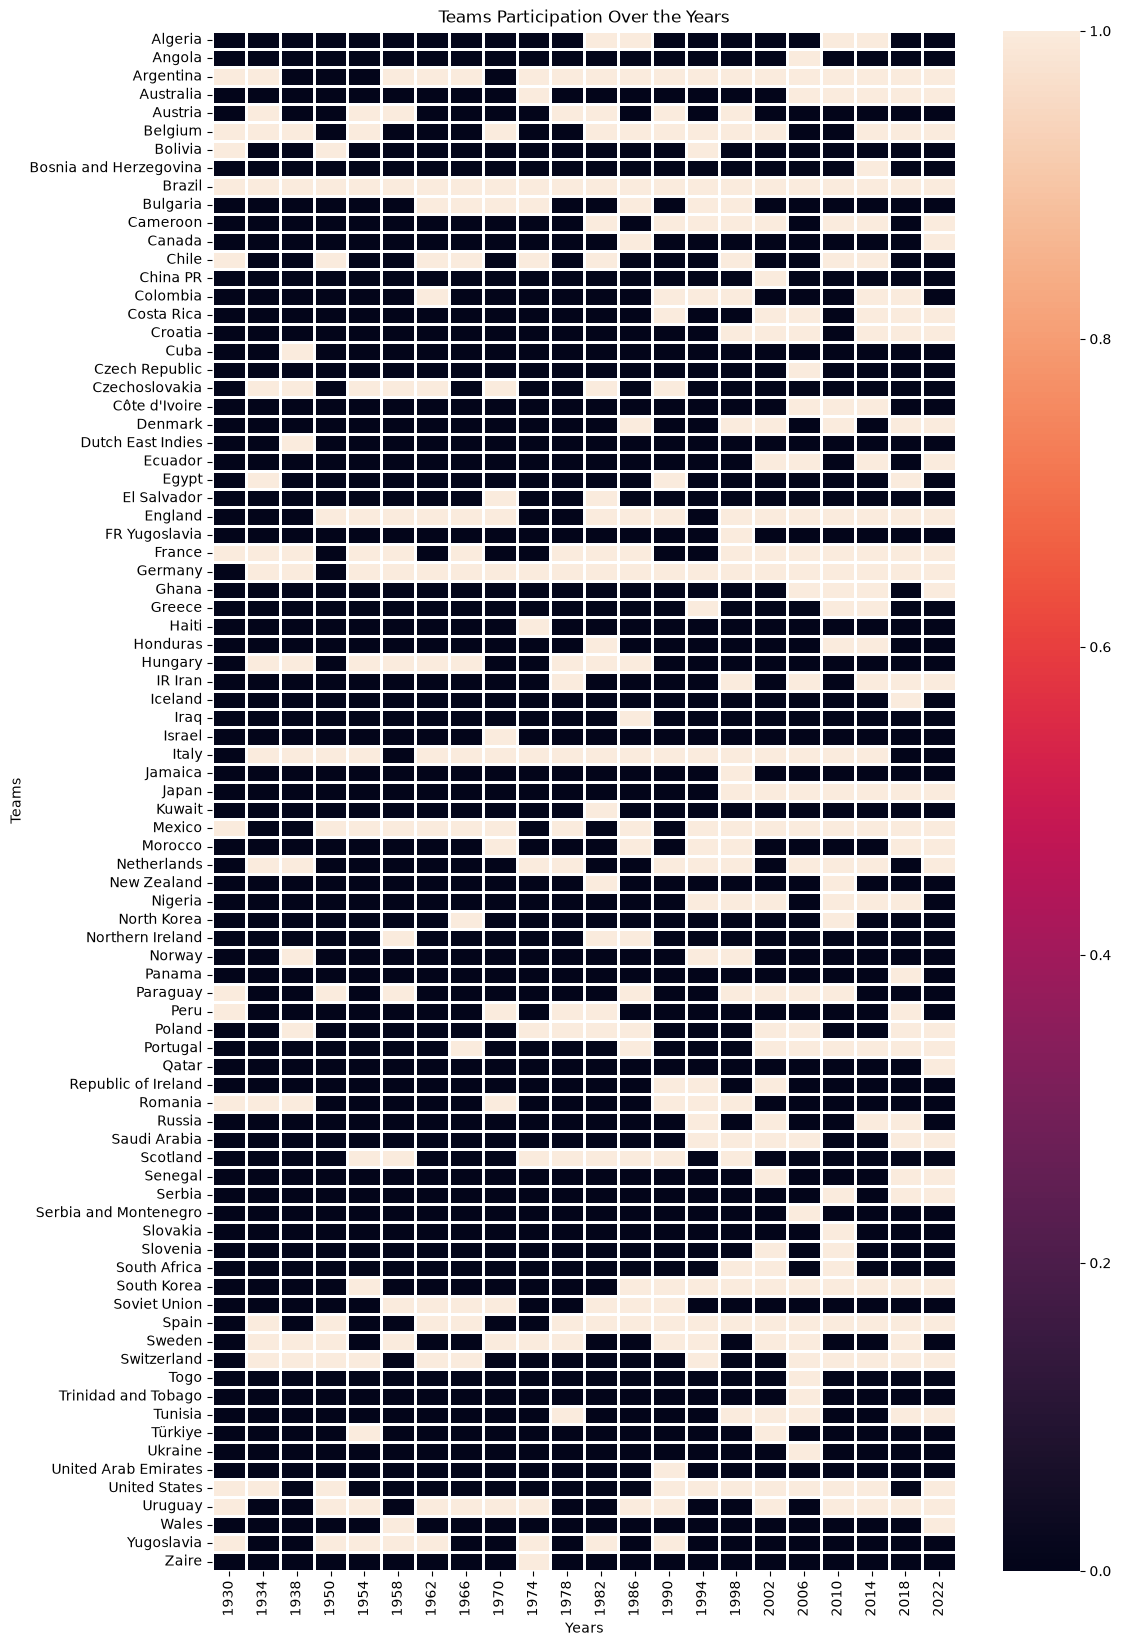

In [241]:
# Now going to visualize 
plt.figure(figsize=(12,20))
sns.heatmap(data=data_pivot,linecolor='white',linewidths=1)
plt.title('Teams Participation Over the Years')
plt.xlabel('Years')
plt.ylabel('Teams')
plt.show()

### OBSERVATIONS
   - Brazil is the only country to play all editions of the FIFA cup.
   - Countries are Qatar , Canada , Wales are new to the tournament.
   - Countires like Cuba, Israel , Kuwait , jamaica, Ukrain , Tongo etc. participated in only 1 edition of FIFA.

In [242]:
ranking_df.head(10)

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46
5,Italy,ITA,UEFA,6,7,1726.14,1713.86
6,Spain,ESP,UEFA,7,6,1715.22,1716.93
7,Netherlands,NED,UEFA,8,8,1694.51,1679.41
8,Portugal,POR,UEFA,9,9,1676.56,1678.65
9,Denmark,DEN,UEFA,10,10,1666.57,1665.47


  - Checking for which the country rank decreased, increased or remain same.

In [243]:
# Now I'm creating a new table for which the teams are remain same. 
same_rank = ranking_df[ranking_df['rank'] == ranking_df['previous_rank']]['team'].tolist()
# for decreased rank 
rank_decrease = ranking_df[ranking_df['rank'] > ranking_df['previous_rank']]['team'].tolist()
# for increased rank 
rank_increase = ranking_df[ranking_df['rank'] < ranking_df['previous_rank']]['team'].tolist()

In [244]:
print(f'Same Rank : {len(same_rank)}')
print(f'Increased Rank : {len(rank_increase)}')
print(f'Decreased Rank : {len(rank_decrease)}')

Same Rank : 66
Increased Rank : 77
Decreased Rank : 68


In [245]:
max_length = max(len(same_rank),len(rank_increase),len(rank_decrease))

In [246]:
# adding None value to same the size 
same_rank += ['None'] * (max_length-len(same_rank))
rank_increase += ['None'] * (max_length-len(rank_increase))
rank_decrease += ['None'] * (max_length-len(rank_decrease))

In [247]:
df = pd.DataFrame({
    'Same Rank' : same_rank,
    'Increased Rank': rank_increase,
    'Decrease Rank': rank_decrease
})
df.fillna('',inplace=True)
df

,Same Rank,Increased Rank,Decrease Rank
0,Brazil,Italy,Spain
1,Belgium,Croatia,Mexico
2,Argentina,Switzerland,Uruguay
3,France,IR Iran,USA
4,England,Serbia,Peru
...,...,...,...
72,None,Timor-Leste,None
73,None,Eritrea,None
74,None,Aruba,None
75,None,Bahamas,None


  - Function to check the country rank. when you give a country name it will show you whether the rank increase, Decrease or remain same.

In [248]:
def find_Rank(country):
    
    result=[]
    for column in df.columns:
        matches = (df[column] == country)
        if matches.any():
            result.append(column)
        
    return result

find_Rank('Brazil')    


['Same Rank']

### Now Starting Advance EDA from here

  - Probability of a Team winning Knockout Matches

In [249]:
# let's Assume we are doing this for Argentina. 
country = 'Argentina'
# Now Finding all the knockout matches of Argentina
Argentina_matches = matches_df[(matches_df['home_team'] == 'Argentina') | (matches_df['away_team'] == 'Argentina')]

knockout_stages = ['Final','Semi-finals','Quarter-finals']
knockout_df = Argentina_matches[Argentina_matches['Round'].isin(knockout_stages)]

df1 = knockout_df['Round'].value_counts().reset_index()
df1.columns=['Round','Total_Matches']

In [250]:
# Function for How many matches are won this particular team when he is in knockout stage.
def get_winner(row):
    
    if ((row['home_total']) > (row['away_total'])):
        return row['home_team']
    else:
        return row['away_team']

In [251]:
knockout_df['winner'] = knockout_df.apply(get_winner,axis=1)

In [252]:
df2 = knockout_df[knockout_df['winner'] == country]['Round'].value_counts().reset_index()
df2.columns=['Round','Total_Matches']

In [253]:
df1

,Round,Total_Matches
0,Quarter-finals,8
1,Final,6
2,Semi-finals,5


In [254]:
df2

,Round,Total_Matches
0,Semi-finals,5
1,Quarter-finals,4
2,Final,3


In [269]:
pd.merge(df1, df2, on="Round", how="inner").fillna(0)

,Round,Total_Matches_x,Total_Matches_y
0,Quarter-finals,8,4
1,Final,6,3
2,Semi-finals,5,5


In [267]:
def calculate_performance(country):
    # Filter matches based on the specified country and rounds
    data = matches_df[
        ((matches_df["home_team"] == country) | (matches_df["away_team"] == country))
        & (
            (matches_df["Round"] == "Final")
            | (matches_df["Round"] == "Semi-finals")
            | (matches_df["Round"] == "Quarter-finals")
        )
    ].copy()

    # Create a DataFrame with the count of matches per round
    df1 = pd.DataFrame(data["Round"].value_counts().reset_index())
    df1.columns = ["Round", "Total Matches"]

    # Function to determine the winner of each match (nested inside)
    def get_winner(row):
        if row["home_total"] > row["away_total"]:
            return row["home_team"]
        else:
            return row["away_team"]

    # Apply the get_winner function to find the winner for each match
    data["winner"] = data.apply(get_winner, axis=1)

    # Create a DataFrame with the count of matches won by this country per round
    df2 = pd.DataFrame(
        data[data["winner"] == country]["Round"].value_counts().reset_index()
    )
    df2.columns = ["Round", "Matches Won"]

    # Merge the two dataframes on the 'Round' column
    # how='left' ensures rounds with 0 wins are still included
    final_df = pd.merge(df1, df2, on="Round", how="left").fillna(0)

    # Convert 'Matches Won' back to an integer after fillna(0)
    final_df["Matches Won"] = final_df["Matches Won"].astype(int)

    # Calculate the percentage of matches won
    final_df["Win Percentage"] = (
        (final_df["Matches Won"] / final_df["Total Matches"]) * 100
    ).round(2)

    return final_df


# --- Example Call ---
result = calculate_performance('Italy')
result


,Round,Total Matches,Matches Won,Win Percentage
0,Quarter-finals,8,6,75.00
1,Semi-finals,7,6,85.71
2,Final,6,4,66.67


### Conclusions 
   - Italy: Teams facing Italy in knockout rounds can expect a challenging match.
   - Italy has a 75% probability of winning in the quarter-finals, an 86% probability of advancing from the semi-finals, and a 67% probability of securing victory in the finals.
   - Spain: if it clears QF its wins title.
   - France: they have good record in QF comparatively not that good record in Semi and Finals.
   - Sweden never reaches a final.